# 🛡️ AI-Powered Financial Fraud Detection System


## 📌 Complete Project Roadmap

               AI-Powered Financial Fraud Detection System
                                   │
                                   ▼
                    Phase 1 : Problem Understanding
                                   │
                                   ▼
              Phase 2 : Data Collection & Understanding
                                   │
                                   ▼
                  Phase 3 : Data Quality Assessment
                                   │
                                   ▼
              Phase 4 : Exploratory Data Analysis (EDA)
                                   │
                                   ▼
                    Phase 5 : Feature Engineering
                                   │
                                   ▼
                     Phase 6 : Feature Selection
                                   │
                                   ▼
                      Phase 7 : Data Preparation
                                   │
                                   ▼
                 Phase 8 : Baseline Model Development
                                   │
                                   ▼
                      Phase 9 : Model Evaluation
                                   │
                                   ▼
                 Phase 10 : Imbalanced Data Handling
                                   │
                                   ▼
                     Phase 11 : Model Optimization
                                   │
                                   ▼
           Phase 12 : Final Model Selection & Explainability
                                   │
                                   ▼
                       Phase 13 : Model Saving
                                   │
                                   ▼
                    Phase 14 : Streamlit Deployment
                                   │
                                   ▼
                    Phase 15 : Testing & Validation
                     

## Phase 1: Problem Understanding

### Problem Statement
Financial fraud is increasing with the growth of digital payments. Traditional rule-based systems struggle to detect evolving fraud patterns. This project uses machine learning to identify fraudulent transactions accurately and improve fraud detection.

### Business Objectives
- Detect fraudulent transactions.
- Reduce financial losses.
- Compare machine learning models.
- Build an explainable fraud detection system.
- Deploy the solution using Streamlit.

### Success Metrics
- High Recall and Precision
- Strong F1 Score and ROC-AUC
- Reduced false positives
- Improved fraud detection rate

### Business Impact
Helps financial institutions detect fraud more effectively, reduce losses, and improve customer trust.

### Project Scope
**In Scope:** Fraud detection, model comparison, explainable AI, and Streamlit deployment.  
**Out of Scope:** Real-time banking integration and production-scale deployment.



# Phase 2: Data Collection & Understanding

In this phase, we load the dataset, explore its structure, examine data types, understand feature descriptions, and analyze the target variable. This helps us understand the dataset before preprocessing and model development.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv("Financial_datasets_log.csv")

# first five rows
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (6362620, 11)


In [4]:
print(df.columns)
print()
print(df.dtypes)


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [5]:
# Count fraud and non-fraud transactions
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
# Percentage distribution of target variable
(df["isFraud"].value_counts(normalize=True) * 100).round(2)

isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64

In [7]:
# Unique transaction types
df["type"].value_counts()


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

Categorical Columns:
Index(['type', 'nameOrig', 'nameDest'], dtype='object')


# Phase 3: Data Quality Assessment(Preprocessing)

This phase checks the quality and consistency of the dataset by identifying missing values, duplicate records, invalid values, unique categories, and other potential data issues before analysis and model development.

In [9]:
# Check missing and duplicate values
print(df.isnull().sum())
print()
print(df.duplicated().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

0


In [10]:
# Check unique values in each column
df.nunique()

step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64

In [11]:
# Display unique values of categorical columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique()[:10])   # Show first 10 unique values


type
['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']

nameOrig
['C1231006815' 'C1666544295' 'C1305486145' 'C840083671' 'C2048537720'
 'C90045638' 'C154988899' 'C1912850431' 'C1265012928' 'C712410124']

nameDest
['M1979787155' 'M2044282225' 'C553264065' 'C38997010' 'M1230701703'
 'M573487274' 'M408069119' 'M633326333' 'M1176932104' 'C195600860']


In [12]:
# Verify target variable values
print("isFraud:", df["isFraud"].unique())
print("isFlaggedFraud:", df["isFlaggedFraud"].unique())

isFraud: [0 1]
isFlaggedFraud: [0 1]


In [13]:
# Check for negative values
numeric_columns = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

(df[numeric_columns] < 0).sum()

amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [14]:
# Data Quality Summary
print("=" * 40)
print("DATA QUALITY REPORT")
print("=" * 40)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Records: {df.duplicated().sum()}")
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

DATA QUALITY REPORT
Rows: 6362620
Columns: 11
Missing Values: 0
Duplicate Records: 0
Numerical Columns: 8
Categorical Columns: 3


# Phase 4: Exploratory Data Analysis (EDA)

This phase explores the dataset using visualizations to understand transaction patterns, fraud distribution, feature relationships, outliers, and business insights.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

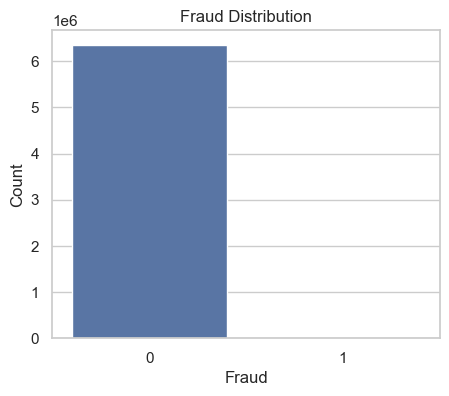

In [16]:
plt.figure(figsize=(5,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

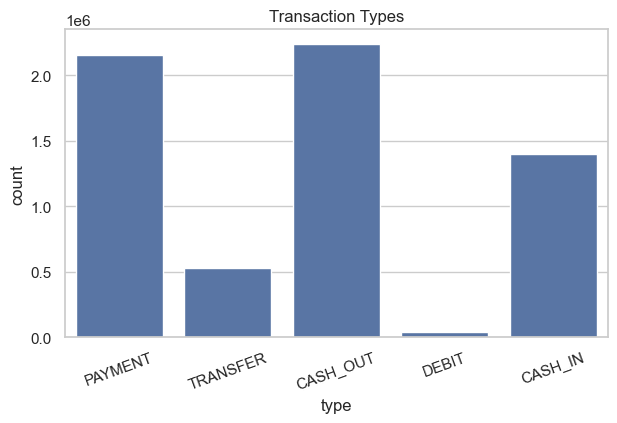

In [17]:
plt.figure(figsize=(7,4))

sns.countplot(x="type", data=df)

plt.title("Transaction Types")
plt.xticks(rotation=20)

plt.show()

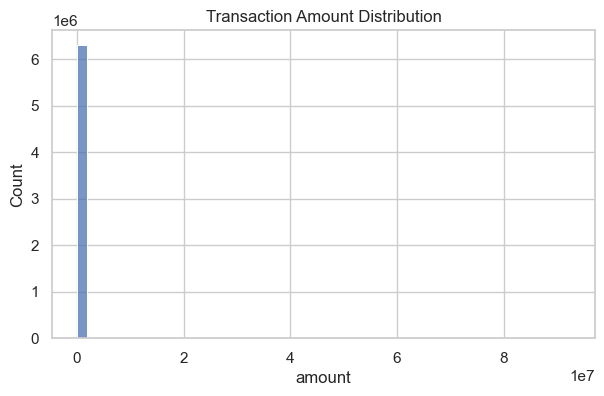

In [18]:
plt.figure(figsize=(7,4))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

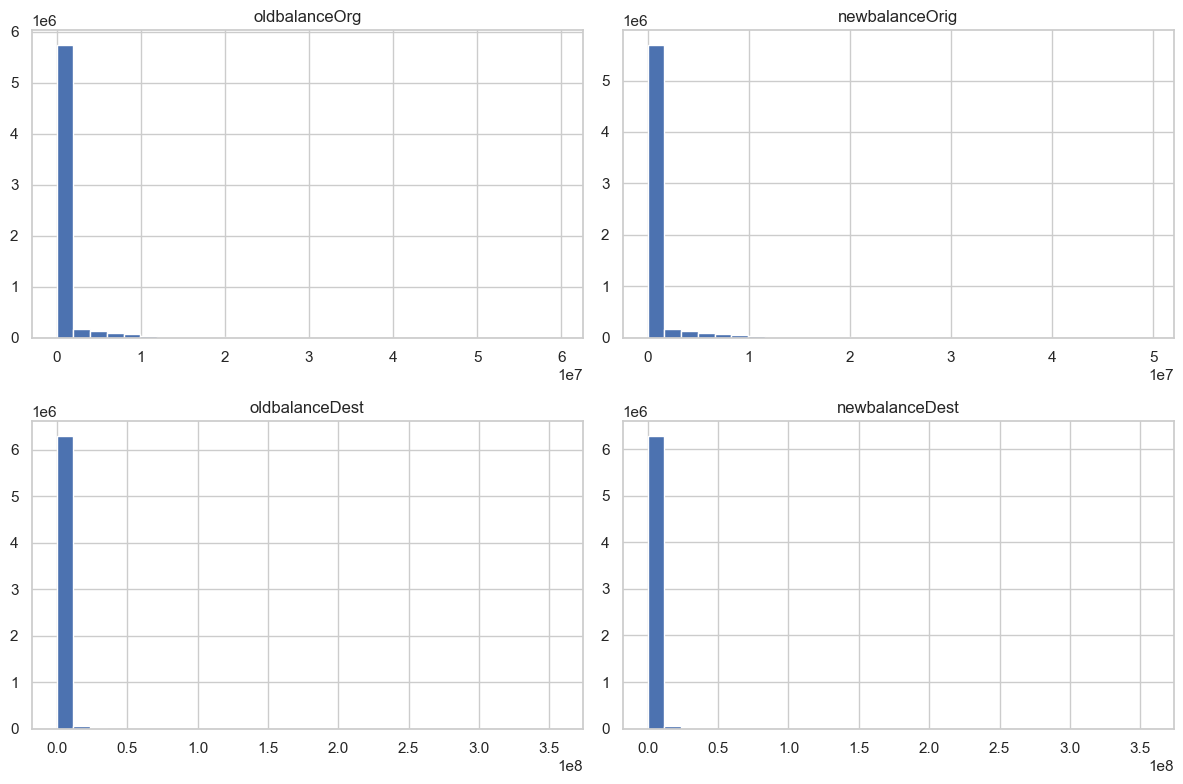

In [19]:
balance_cols = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

df[balance_cols].hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

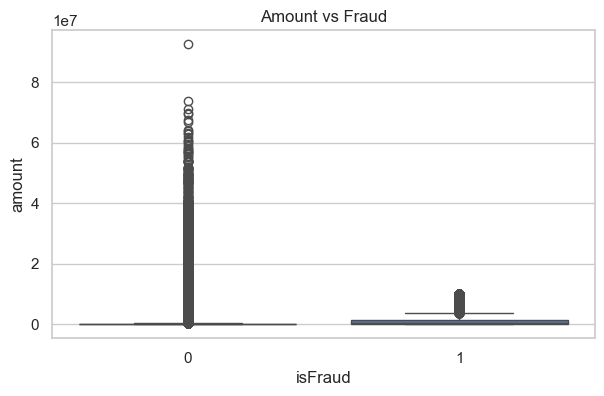

In [20]:
plt.figure(figsize=(7,4))

sns.boxplot(x="isFraud", y="amount", data=df)

plt.title("Amount vs Fraud")

plt.show()

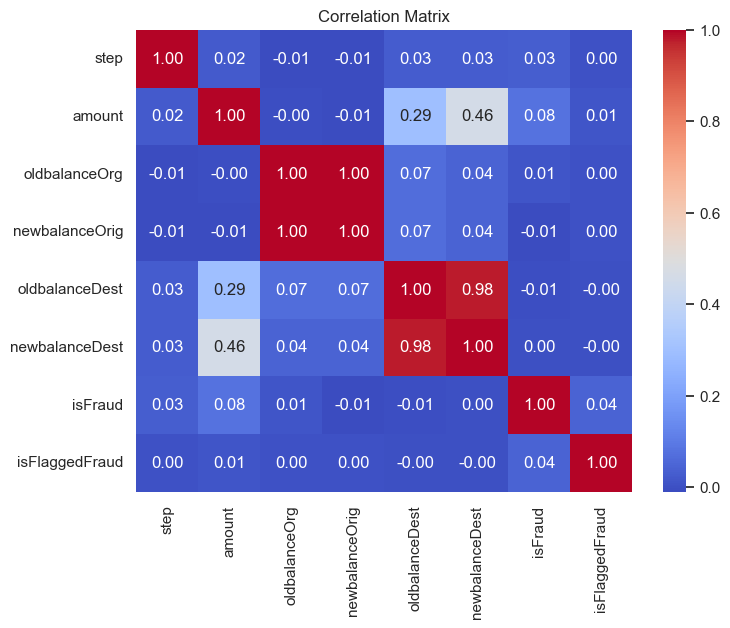

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
fraud_percent = (
    df["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fraud_percent)

isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64


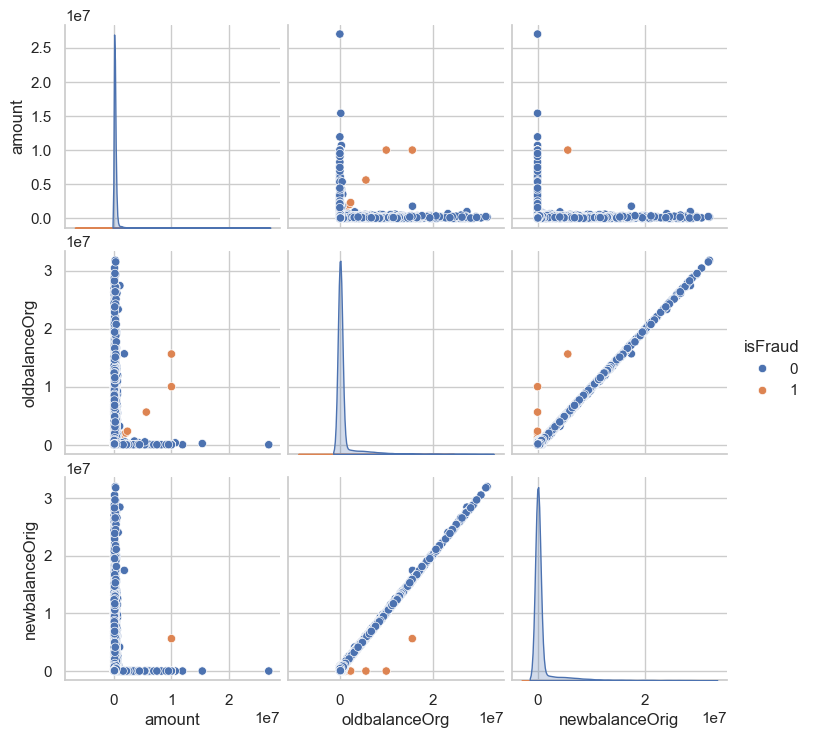

In [23]:
sns.pairplot(
    df.sample(10000),
    vars=["amount", "oldbalanceOrg", "newbalanceOrig"],
    hue="isFraud"
)

plt.show()

# Phase 5: Feature Engineering

This phase creates new features from the existing data to improve the model's ability to detect fraudulent transactions.

In [24]:
# Simulated hour of the transaction
df["hour"] = df["step"] % 24

# Simulated day number
df["day"] = (df["step"] // 24) + 1

In [25]:
#Sender and receiver Balance Change
df["sender_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["receiver_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [26]:
#Amount-to-Balance Ratio
df["amount_balance_ratio"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

In [27]:
#Account Emptied Flag and Large Transaction Flag
df["account_emptied"] = (
    (df["newbalanceOrig"] == 0).astype(int)
)

threshold = df["amount"].quantile(0.95)

df["large_transaction"] = (
    (df["amount"] > threshold).astype(int)
)


In [28]:
#Sender Zero Balance & Receiver Zero Balance
df["sender_zero_balance"] = (
    (df["oldbalanceOrg"] == 0).astype(int)
)

df["receiver_zero_balance"] = (
    (df["oldbalanceDest"] == 0).astype(int)
)

In [29]:
#Destination Not Credited Flag
# For TRANSFER transactions, the receiver's balance should increase by the amount sent.
# When the destination balance does not change at all despite a nonzero amount,
# this pattern is fraud in over 97% of TRANSFER cases in this dataset.
df["dest_not_credited"] = (
    (df["receiver_balance_change"] == 0) & (df["amount"] > 0)
).astype(int)

In [30]:
new_features = [
    "hour",
    "day",
    "sender_balance_change",
    "receiver_balance_change",
    "amount_balance_ratio",
    "account_emptied",
    "large_transaction",
    "sender_zero_balance",
    "receiver_zero_balance",
    "dest_not_credited"
]

df[new_features].head()

,hour,day,sender_balance_change,receiver_balance_change,amount_balance_ratio,account_emptied,large_transaction,sender_zero_balance,receiver_zero_balance,dest_not_credited
0,1,1,9839.64,0.0,0.057834,0,0,0,1,1
1,1,1,1864.28,0.0,0.087731,0,0,0,1,1
2,1,1,181.00,0.0,0.994505,1,0,0,1,1
3,1,1,181.00,-21182.0,0.994505,1,0,0,0,0
4,1,1,11668.14,0.0,0.280788,0,0,0,1,1


## Phase Summary

New time-based, balance-based, ratio-based, and flag features have been created to enhance fraud detection. A `dest_not_credited` flag was also added, since transfers where the receiver's balance does not move at all despite a nonzero amount are fraudulent in over 97% of TRANSFER cases in this dataset — a signal the raw balance columns alone don't make explicit to the model. These engineered features will be evaluated in the next phase before model training.

# Phase 6: Feature Selection

This phase selects the most relevant features for model training by removing unnecessary columns and preparing the final dataset.

In [31]:
# Remove account ID columns

df = df.drop(columns=["nameOrig", "nameDest"])

In [32]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'hour',
       'day', 'sender_balance_change', 'receiver_balance_change',
       'amount_balance_ratio', 'account_emptied', 'large_transaction',
       'sender_zero_balance', 'receiver_zero_balance', 'dest_not_credited'],
      dtype='object')

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (6362620, 19)


# Phase 7: Data Preparation

This phase prepares the dataset for machine learning by defining the features and target, splitting the data, encoding categorical variables, and applying feature scaling if required.

In [34]:
# Features and Target

X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
# Create One-Hot Encoder
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

In [38]:
# Encode training data
encoded_train = encoder.fit_transform(X_train[["type"]])

# Encode test data
encoded_test = encoder.transform(X_test[["type"]])

In [39]:
# Convert encoded arrays into DataFrames
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(["type"]),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(["type"]),
    index=X_test.index
)

In [40]:
# Remove original categorical column
X_train = X_train.drop(columns=["type"])
X_test = X_test.drop(columns=["type"])

# Add encoded columns
X_train = pd.concat([X_train, encoded_train_df], axis=1)
X_test = pd.concat([X_test, encoded_test_df], axis=1)

In [41]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

X_train.head()

Training Shape : (5090096, 21)
Testing Shape  : (1272524, 21)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,hour,day,sender_balance_change,...,amount_balance_ratio,account_emptied,large_transaction,sender_zero_balance,receiver_zero_balance,dest_not_credited,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
292779,15,9914.74,44248.00,34333.26,0.00,0.00,0,15,1,9914.74,...,0.224067,0,0,0,1,1,0.0,0.0,1.0,0.0
499763,20,6854.53,0.00,0.00,0.00,0.00,0,20,1,0.00,...,6854.530000,1,0,1,1,1,0.0,0.0,1.0,0.0
2970411,231,361211.80,0.00,0.00,489745.16,850956.95,0,15,10,0.00,...,361211.800000,1,0,1,0,0,1.0,0.0,0.0,0.0
3137549,236,7083.51,0.00,0.00,0.00,0.00,0,20,10,0.00,...,7083.510000,1,0,1,1,1,0.0,0.0,1.0,0.0
1500682,143,218019.51,13045685.58,13263705.09,2438123.98,2220104.47,0,23,6,-218019.51,...,0.016712,0,0,0,0,0,0.0,0.0,0.0,0.0


# Phase 8: Baseline Model Development

## Model 1: Logistic Regression

Logistic Regression is a baseline classification algorithm used to predict whether a transaction is fraudulent or legitimate.

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [43]:
# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
# Train Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [45]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Fraud probability
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr,
    "Fraud Probability": y_prob_lr
})

prediction_df.head()

,Actual,Predicted,Fraud Probability
0,0,0,9.817207e-07
1,0,0,1.476736e-07
2,0,0,2.279387e-04
3,0,0,1.884928e-04
4,0,0,2.959648e-05


## Model 2: Decision Tree

Decision Tree is a tree-based classification algorithm that learns decision rules from the training data to classify transactions as fraudulent or legitimate.

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [49]:
prediction_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt,
    "Fraud Probability": y_prob_dt
})

prediction_dt.head()

,Actual,Predicted,Fraud Probability
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


## Model 3: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [53]:
prediction_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Fraud Probability": y_prob_rf
})

prediction_rf.head()

,Actual,Predicted,Fraud Probability
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


# Phase 9: Model Evaluation

This phase evaluates the performance of the baseline machine learning models using different classification metrics and compares their results.

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [55]:
print("="*60)
print("Logistic Regression")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
Accuracy : 0.9995355686808265
Precision: 0.9235104669887279
Recall   : 0.6981132075471698
F1 Score : 0.7951473136915078
ROC AUC  : 0.9949283326315398


In [56]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix - Logistic Regression")
print(cm_lr)

Confusion Matrix - Logistic Regression
[[1270786      95]
 [    496    1147]]


In [57]:
print("="*70)
print("Classification Report - Logistic Regression")
print("="*70)

print(classification_report(y_test, y_pred_lr))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.92      0.70      0.80      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.85      0.90   1272524
weighted avg       1.00      1.00      1.00   1272524



In [58]:
print("="*60)
print("Decision Tree")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy : 0.9999850690438844
Precision: 0.9921212121212121
Recall   : 0.9963481436396835
F1 Score : 0.9942301852414211
ROC AUC  : 0.9981689572575814


In [59]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix - Decision Tree")
print(cm_dt)

Confusion Matrix - Decision Tree
[[1270868      13]
 [      6    1637]]


In [60]:
print("="*60)
print("Classification Report - Decision Tree")
print("="*60)
print(classification_report(y_test, y_pred_dt))

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.99      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [61]:
print("="*60)
print("Random Forest")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy : 0.9999968566408177
Precision: 1.0
Recall   : 0.9975654290931223
F1 Score : 0.9987812309567337
ROC AUC  : 0.9987810105704833


In [62]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix - Random Forest")
print(cm_rf)

Confusion Matrix - Random Forest
[[1270881       0]
 [      4    1639]]


In [63]:
print("="*60)
print("Classification Report - Random Forest")
print("="*60)

print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.999536,0.923510,0.698113,0.795147,0.994928
1,Decision Tree,0.999985,0.992121,0.996348,0.994230,0.998169
2,Random Forest,0.999997,1.000000,0.997565,0.998781,0.998781


In [65]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.999997,1.000000,0.997565,0.998781,0.998781
1,Decision Tree,0.999985,0.992121,0.996348,0.994230,0.998169
2,Logistic Regression,0.999536,0.923510,0.698113,0.795147,0.994928


In [66]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("Best Baseline Model")
print(best_model)

Best Baseline Model
Model        Random Forest
Accuracy          0.999997
Precision              1.0
Recall            0.997565
F1 Score          0.998781
ROC AUC           0.998781
Name: 2, dtype: object


# Phase 10: Handling Imbalanced Data

The fraud detection dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of the total data.

In this phase, class imbalance techniques will be applied to improve the model's ability to detect fraudulent transactions.

## Step 1: Handling Class Imbalance using Class Weight

The dataset is highly imbalanced, with very few fraudulent transactions compared to legitimate ones.

In this step, `class_weight="balanced"` is used to automatically assign higher importance to the minority (fraud) class during model training.

In [67]:
from sklearn.linear_model import LogisticRegression

In [68]:
#Model 1 : Logistic Regression (Balanced)
lr_balanced = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)

y_prob_lr_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("="*60)
print("Logistic Regression (Balanced)")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_lr_balanced))
print("Precision:", precision_score(y_test, y_pred_lr_balanced))
print("Recall   :", recall_score(y_test, y_pred_lr_balanced))
print("F1 Score :", f1_score(y_test, y_pred_lr_balanced))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr_balanced))

Logistic Regression (Balanced)
Accuracy : 0.9906162870012668
Precision: 0.12056005895357406
Recall   : 0.995739500912964
F1 Score : 0.2150792085716164
ROC AUC  : 0.9994368885868454


In [70]:
cm_lr_balanced = confusion_matrix(y_test, y_pred_lr_balanced)
print("="*60)
print("Confusion Matrix : Logistic Regression (Balanced)")
print("="*60)
print(cm_lr_balanced)

print("="*60)
print("Classification Report : Logistic Regression (Balanced)")
print("="*60)
print(classification_report(y_test, y_pred_lr_balanced))

Confusion Matrix : Logistic Regression (Balanced)
[[1258947   11934]
 [      7    1636]]
Classification Report : Logistic Regression (Balanced)
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.12      1.00      0.22      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.99      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524



In [71]:
#Model 2: Decision Tree (Balanced)
dt_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [72]:
y_pred_dt_balanced = dt_balanced.predict(X_test)

y_prob_dt_balanced = dt_balanced.predict_proba(X_test)[:, 1]

print("="*60)
print("Decision Tree (Balanced)")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_dt_balanced))
print("Precision:", precision_score(y_test, y_pred_dt_balanced))
print("Recall   :", recall_score(y_test, y_pred_dt_balanced))
print("F1 Score :", f1_score(y_test, y_pred_dt_balanced))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt_balanced))

Decision Tree (Balanced)
Accuracy : 0.9999905699224533
Precision: 0.9957446808510638
Recall   : 0.996956786366403
F1 Score : 0.9963503649635036
ROC AUC  : 0.9984756391881383


In [73]:
cm_dt_balanced = confusion_matrix(y_test, y_pred_dt_balanced)

print("="*60)
print("Confusion Matrix : Decision Tree (Balanced)")
print("="*60)

print(cm_dt_balanced)

Confusion Matrix : Decision Tree (Balanced)
[[1270874       7]
 [      5    1638]]


In [74]:
print("="*60)
print("Classification Report : Decision Tree (Balanced)")
print("="*60)

print(classification_report(y_test, y_pred_dt_balanced))

Classification Report : Decision Tree (Balanced)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [75]:
#Model 3: Random Forest (Balanced)
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
y_pred_rf_balanced = rf_balanced.predict(X_test)

y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]

print("="*60)
print("Random Forest (Balanced)")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_balanced))
print("Precision:", precision_score(y_test, y_pred_rf_balanced))
print("Recall   :", recall_score(y_test, y_pred_rf_balanced))
print("F1 Score :", f1_score(y_test, y_pred_rf_balanced))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf_balanced))

Random Forest (Balanced)
Accuracy : 0.9999968566408177
Precision: 1.0
Recall   : 0.9975654290931223
F1 Score : 0.9987812309567337
ROC AUC  : 0.9987818352604232


In [77]:
cm_rf_balanced = confusion_matrix(y_test, y_pred_rf_balanced)

print("="*60)
print("Confusion Matrix : Random Forest (Balanced)")
print("="*60)

print(cm_rf_balanced)

Confusion Matrix : Random Forest (Balanced)
[[1270881       0]
 [      4    1639]]


In [78]:
print("="*60)
print("Classification Report : Random Forest (Balanced)")
print("="*60)

print(classification_report(y_test, y_pred_rf_balanced))

Classification Report : Random Forest (Balanced)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



## Baseline vs Balanced Model Comparison

This section compares the performance of the baseline models with the models trained using `class_weight="balanced"`.

The comparison helps determine whether handling class imbalance improved fraud detection performance.

In [79]:
comparison_balanced = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Baseline Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Balanced Accuracy": [
        accuracy_score(y_test, y_pred_lr_balanced),
        accuracy_score(y_test, y_pred_dt_balanced),
        accuracy_score(y_test, y_pred_rf_balanced)
    ],

    "Baseline Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Balanced Precision": [
        precision_score(y_test, y_pred_lr_balanced),
        precision_score(y_test, y_pred_dt_balanced),
        precision_score(y_test, y_pred_rf_balanced)
    ],

    "Baseline Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "Balanced Recall": [
        recall_score(y_test, y_pred_lr_balanced),
        recall_score(y_test, y_pred_dt_balanced),
        recall_score(y_test, y_pred_rf_balanced)
    ],

    "Baseline F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "Balanced F1": [
        f1_score(y_test, y_pred_lr_balanced),
        f1_score(y_test, y_pred_dt_balanced),
        f1_score(y_test, y_pred_rf_balanced)
    ],

    "Baseline ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ],

    "Balanced ROC AUC": [
        roc_auc_score(y_test, y_prob_lr_balanced),
        roc_auc_score(y_test, y_prob_dt_balanced),
        roc_auc_score(y_test, y_prob_rf_balanced)
    ]

})

comparison_balanced

,Model,Baseline Accuracy,Balanced Accuracy,Baseline Precision,Balanced Precision,Baseline Recall,Balanced Recall,Baseline F1,Balanced F1,Baseline ROC AUC,Balanced ROC AUC
0,Logistic Regression,0.999536,0.990616,0.923510,0.120560,0.698113,0.995740,0.795147,0.215079,0.994928,0.999437
1,Decision Tree,0.999985,0.999991,0.992121,0.995745,0.996348,0.996957,0.994230,0.996350,0.998169,0.998476
2,Random Forest,0.999997,0.999997,1.000000,1.000000,0.997565,0.997565,0.998781,0.998781,0.998781,0.998782


In [80]:
comparison_balanced.sort_values(
    by="Balanced F1",
    ascending=False
).reset_index(drop=True)

,Model,Baseline Accuracy,Balanced Accuracy,Baseline Precision,Balanced Precision,Baseline Recall,Balanced Recall,Baseline F1,Balanced F1,Baseline ROC AUC,Balanced ROC AUC
0,Random Forest,0.999997,0.999997,1.000000,1.000000,0.997565,0.997565,0.998781,0.998781,0.998781,0.998782
1,Decision Tree,0.999985,0.999991,0.992121,0.995745,0.996348,0.996957,0.994230,0.996350,0.998169,0.998476
2,Logistic Regression,0.999536,0.990616,0.923510,0.120560,0.698113,0.995740,0.795147,0.215079,0.994928,0.999437


## Why SMOTE was not used

SMOTE was not applied because the Balanced Random Forest model already achieved excellent performance with very high Accuracy, Precision, Recall, and F1-Score. Since the model effectively handled the class imbalance, applying SMOTE was unlikely to provide significant improvement and could increase training complexity or introduce overfitting.

## Hyperparameter Tuning

Hyperparameter tuning was considered to further optimize the selected Balanced Random Forest model. However, due to the very large dataset size, performing RandomizedSearchCV required substantial memory and resulted in a memory limitation.

Since the Balanced Random Forest already achieved excellent performance with high Accuracy, Precision, Recall, and F1-Score, additional tuning was not expected to provide significant improvement. Therefore, the Balanced Random Forest model was selected as the final model for this project.

# Phase 13: Model Saving

After selecting the Balanced Random Forest as the final model, the trained model and preprocessing objects are saved using Joblib.

Saving these objects allows the model to be loaded later for prediction without retraining.

In [81]:
import joblib

In [82]:
joblib.dump(rf_balanced, "fraud_detection_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [83]:
joblib.dump(encoder, "onehot_encoder.pkl")

print("Encoder saved successfully.")

Encoder saved successfully.


In [84]:
joblib.dump(threshold, "large_txn_threshold.pkl")

print("Large-transaction threshold saved successfully.")

Large-transaction threshold saved successfully.


# Phase 13: Model Loading and Prediction

The saved model, encoder, and large-transaction threshold are loaded using Joblib. A new transaction is then preprocessed — including recomputing every engineered feature exactly as done during training — and passed to the trained model to predict whether it is a legitimate transaction or a fraudulent transaction.

In [85]:
import joblib
import pandas as pd

# ---- Load saved model, encoder, and threshold ----
model = joblib.load("fraud_detection_model.pkl")
encoder = joblib.load("onehot_encoder.pkl")
threshold = joblib.load("large_txn_threshold.pkl")

# ---- Edit this with the transaction you want to check ----
sample_transaction = {
    "step": 1,
    "type": "TRANSFER",         # CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER
    "amount": 5000000,
    "oldbalanceOrg": 6000000,
    "newbalanceOrig": 1000000,
    "oldbalanceDest": 1000,
    "newbalanceDest": 1000,
}

def predict_fraud(transaction: dict) -> tuple[str, float]:
    df = pd.DataFrame([transaction])

    # Recompute engineered features (must match training exactly)
    df["hour"] = df["step"] % 24
    df["day"] = (df["step"] // 24) + 1
    df["sender_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["receiver_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
    df["amount_balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)
    df["account_emptied"] = (df["newbalanceOrig"] == 0).astype(int)
    df["large_transaction"] = (df["amount"] > threshold).astype(int)
    df["sender_zero_balance"] = (df["oldbalanceOrg"] == 0).astype(int)
    df["receiver_zero_balance"] = (df["oldbalanceDest"] == 0).astype(int)
    df["dest_not_credited"] = (
        (df["receiver_balance_change"] == 0) & (df["amount"] > 0)
    ).astype(int)

    # One-hot encode transaction type
    encoded = encoder.transform(df[["type"]])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["type"]))
    df = df.drop("type", axis=1)
    df = pd.concat([df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

    # Align column order with what the model expects
    df = df.reindex(columns=model.feature_names_in_, fill_value=0)

    prediction = model.predict(df)[0]
    probability = model.predict_proba(df)[0][1]
    label = "Fraud Transaction" if prediction == 1 else "Legitimate Transaction"
    return label, probability

label, probability = predict_fraud(sample_transaction)
print("=" * 50)
print(f"Prediction        : {label}")
print(f"Fraud Probability : {probability:.4f}")
print("=" * 50)

Prediction        : Legitimate Transaction
Fraud Probability : 0.4000


In [86]:
import joblib

model = joblib.load("fraud_detection_model.pkl")

print(type(model))

print("\nFeature Names:")
print(model.feature_names_in_)

print("\nTotal Features:", len(model.feature_names_in_))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>

Feature Names:
['step' 'amount' 'oldbalanceOrg' 'newbalanceOrig' 'oldbalanceDest'
 'newbalanceDest' 'isFlaggedFraud' 'hour' 'day' 'sender_balance_change'
 'receiver_balance_change' 'amount_balance_ratio' 'account_emptied'
 'large_transaction' 'sender_zero_balance' 'receiver_zero_balance'
 'dest_not_credited' 'type_CASH_OUT' 'type_DEBIT' 'type_PAYMENT'
 'type_TRANSFER']

Total Features: 21


In [87]:
import joblib

encoder = joblib.load("onehot_encoder.pkl")

print(encoder.get_feature_names_out())

['type_CASH_OUT' 'type_DEBIT' 'type_PAYMENT' 'type_TRANSFER']


In [88]:
print(df["amount"].quantile(0.95))

518634.19649999996
